<a href="https://colab.research.google.com/github/nicklausnathanieltiu23p76078-wq/PythonforDataScienceandAI_YoutubeAPI_Group16/blob/main/YouTubeDataThesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
youtube_categories = {
    1: "Film & Animation",
    2: "Autos & Vehicles",
    10: "Music",
    15: "Pets & Animals",
    20: "Gaming",
    22: "People & Blogs",
    23: "Comedy",
    24: "Entertainment",
    25: "News & Politics",
    26: "Howto & Style",
    28: "Science & Technology",
    29: "Nonprofits & Activism"
}

In [ ]:
import pandas as pd
from googleapiclient.discovery import build

api_key = ""
youtube = build('youtube', 'v3', developerKey=api_key)

video_data = []

for category_id, category_name in youtube_categories.items():
  request = youtube.videos().list(
    part="contentDetails,snippet,statistics",
    chart="mostPopular",
    regionCode="US",
    videoCategoryId=category_id,
    maxResults=50
  )
  response = request.execute()

  for video in response['items']:
    title = video['snippet']['title']
    channel = video['snippet']['channelTitle']
    channel_id = video['snippet']['channelId']
    duration = video['contentDetails']['duration']
    views = int(video['statistics']['viewCount'])
    likes = int(video['statistics'].get('likeCount', 0))

    video_data.append({
        'Title': title,
        'Channel': channel,
        'Channel_ID': channel_id,
        'Duration': duration,
        'Views': views,
        'Likes': likes,
        'Category': category_name
    })

df_videos = pd.DataFrame(video_data)
df_videos

,Title,Channel,Channel_ID,Duration,Views,Likes,Category
0,The grandpa didn’t fall for that 💀,MovieLuxeShorts,UCxcwb1pqg2BtlR1AWSEX-MA,PT1M2S,11632842,640642,Film & Animation
1,"If you win the game,I’ll let you go.#movie #sh...",AllAccess TV,UCkb80lSeHu2n4lA6dwdRQ5g,PT58S,13905352,853867,Film & Animation
2,"""Get In The Car""|Bad Boys: Ride or Die (2024)|...",Clinjo AE,UCgcX8KN9tjesfSg1KYW8JMA,PT56S,17814894,0,Film & Animation
3,His parents were surprised by his change.#shorts,PureVision,UCFCiuH9RyKztPPi6hoTm0NQ,PT1M16S,12639989,929326,Film & Animation
4,Marvel Rejected Chris Hemsworth for Thor at Fi...,MRZ NOISYBOY,UCuHDUjCQ5G5elOOgBRopuZQ,PT22S,3734039,206542,Film & Animation
...,...,...,...,...,...,...,...
527,Apple’s Biggest Scam ​⁠@Waveform,Fuel Dose,UC1HOOCKGrELLsoHRSDnPDaQ,PT30S,199539,6967,Science & Technology
528,iShowSpeed Finally Bought the iPhone 17 Pro Ma...,NetSpeed7,UCq1xDLvVEIG3qLgDPGfgK5A,PT43S,960023,48201,Science & Technology
529,Video projectors used to be ridiculously cool,Technology Connections,UCy0tKL1T7wFoYcxCe0xjN6Q,PT34M40S,1285993,67389,Science & Technology
530,We need your help!,Ben Esherick,UCFXCGN9-roeqdFAatAwG8ew,PT54S,559609,71567,Nonprofits & Activism


# Explanotary Data Analysis

In [ ]:
df_videos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       532 non-null    object
 1   Channel     532 non-null    object
 2   Channel_ID  532 non-null    object
 3   Duration    532 non-null    object
 4   Views       532 non-null    int64 
 5   Likes       532 non-null    int64 
 6   Category    532 non-null    object
dtypes: int64(2), object(5)
memory usage: 29.2+ KB


In [ ]:
df_videos.describe()

,Views,Likes
count,5.320000e+02,5.320000e+02
mean,5.441110e+06,2.322374e+05
std,7.865160e+06,3.257376e+05
min,1.651900e+04,0.000000e+00
25%,6.535015e+05,1.766675e+04
50%,2.570142e+06,1.010100e+05
75%,7.143824e+06,3.245148e+05
max,7.479083e+07,2.622824e+06


In [ ]:
df_videos.shape

(532, 7)

# Research Question 1

Does channel age and number of videos posted affect how many subscribers a channel has?

## Hyphothesis 1

1.   H₀ (null): Channel age and total video has no significant impact to subscriber count.
2.   H₁ (alternative): The older the channel age is and the more videos they have, the more subscribers they have. *italicized text*

In [ ]:
unique_channels = df_videos['Channel_ID'].unique().tolist()

channel_data = []

unique_channels = [channel_id for channel_id in unique_channels if channel_id]

for i in range(0, len(unique_channels), 50):
    request = youtube.channels().list(
        part="snippet,statistics",
        id=",".join(unique_channels[i:i+50])
    )
    response = request.execute()

    for item in response['items']:
        channel_data.append({
            'Channel_ID': item['id'],
            'Channel_Title': item['snippet']['title'],
            'PublishedAt': item['snippet']['publishedAt'],
            'Subscribers': int(item['statistics'].get('subscriberCount', 0)),
            'VideoCount': int(item['statistics'].get('videoCount', 0))
        })

df_channels = pd.DataFrame(channel_data)
df_channels

,Channel_ID,Channel_Title,PublishedAt,Subscribers,VideoCount
0,UCAnPqNomicDKFV4GVOkBBOw,PunchLine Comedy,2019-01-22T00:33:44Z,35400,357
1,UCVge8FcdNub_Lc4gqPjYyDg,TwinCoconuts,2013-01-16T23:27:01Z,1110000,1049
2,UCtPNQKbuCsxfCgCxkQ3OSmA,Psycho Thinker,2020-07-03T11:57:44.32503Z,46600,602
3,UCV8PaUhFshDnz6WpO3XUezA,Arha Vewadi,2025-09-09T11:39:12.457509Z,24900,29
4,UCqFzWxSCi39LnW1JKFR3efg,Saturday Night Live,2013-07-23T21:32:27Z,16300000,9540
...,...,...,...,...,...
443,UCWFKCr40YwOZQx8FHU_ZqqQ,JerryRigEverything,2012-07-23T07:07:54Z,9670000,1441
444,UCuwJoiGWRxPYStBp0l0WuZw,Luke Davidson,2012-01-09T19:05:33Z,17600000,1759
445,UCsCkNhjgicjxNBzB1X9cZsg,American MJD,2025-01-27T01:53:32.385955Z,21500,229
446,UCK0DNTTjUx8rOb80JjUrn2A,SURJO FACT 2,2025-08-30T02:22:45.62131Z,127000,57


In [ ]:
from datetime import datetime

df_channels['PublishedAt'] = pd.to_datetime(df_channels['PublishedAt'], format='mixed')
df_channels['FormattedDate'] = df_channels['PublishedAt'].dt.strftime('%Y-%m-%d')

today = pd.Timestamp(datetime.now().date())
df_channels['ChannelAge'] = (today - pd.to_datetime(df_channels['FormattedDate'])).dt.days // 30

df_channels

,Channel_ID,Channel_Title,PublishedAt,Subscribers,VideoCount,FormattedDate,ChannelAge
0,UCAnPqNomicDKFV4GVOkBBOw,PunchLine Comedy,2019-01-22 00:33:44+00:00,35400,357,2019-01-22,81
1,UCVge8FcdNub_Lc4gqPjYyDg,TwinCoconuts,2013-01-16 23:27:01+00:00,1110000,1049,2013-01-16,155
2,UCtPNQKbuCsxfCgCxkQ3OSmA,Psycho Thinker,2020-07-03 11:57:44.325030+00:00,46600,602,2020-07-03,64
3,UCV8PaUhFshDnz6WpO3XUezA,Arha Vewadi,2025-09-09 11:39:12.457509+00:00,24900,29,2025-09-09,1
4,UCqFzWxSCi39LnW1JKFR3efg,Saturday Night Live,2013-07-23 21:32:27+00:00,16300000,9540,2013-07-23,148
...,...,...,...,...,...,...,...
443,UCWFKCr40YwOZQx8FHU_ZqqQ,JerryRigEverything,2012-07-23 07:07:54+00:00,9670000,1441,2012-07-23,161
444,UCuwJoiGWRxPYStBp0l0WuZw,Luke Davidson,2012-01-09 19:05:33+00:00,17600000,1759,2012-01-09,167
445,UCsCkNhjgicjxNBzB1X9cZsg,American MJD,2025-01-27 01:53:32.385955+00:00,21500,229,2025-01-27,8
446,UCK0DNTTjUx8rOb80JjUrn2A,SURJO FACT 2,2025-08-30 02:22:45.621310+00:00,127000,57,2025-08-30,1


In [ ]:
df_cleaned = df_channels[df_channels['ChannelAge'] != 0]
df_cleaned

,Channel_ID,Channel_Title,PublishedAt,Subscribers,VideoCount,FormattedDate,ChannelAge
0,UCAnPqNomicDKFV4GVOkBBOw,PunchLine Comedy,2019-01-22 00:33:44+00:00,35400,357,2019-01-22,81
1,UCVge8FcdNub_Lc4gqPjYyDg,TwinCoconuts,2013-01-16 23:27:01+00:00,1110000,1049,2013-01-16,155
2,UCtPNQKbuCsxfCgCxkQ3OSmA,Psycho Thinker,2020-07-03 11:57:44.325030+00:00,46600,602,2020-07-03,64
3,UCV8PaUhFshDnz6WpO3XUezA,Arha Vewadi,2025-09-09 11:39:12.457509+00:00,24900,29,2025-09-09,1
4,UCqFzWxSCi39LnW1JKFR3efg,Saturday Night Live,2013-07-23 21:32:27+00:00,16300000,9540,2013-07-23,148
...,...,...,...,...,...,...,...
443,UCWFKCr40YwOZQx8FHU_ZqqQ,JerryRigEverything,2012-07-23 07:07:54+00:00,9670000,1441,2012-07-23,161
444,UCuwJoiGWRxPYStBp0l0WuZw,Luke Davidson,2012-01-09 19:05:33+00:00,17600000,1759,2012-01-09,167
445,UCsCkNhjgicjxNBzB1X9cZsg,American MJD,2025-01-27 01:53:32.385955+00:00,21500,229,2025-01-27,8
446,UCK0DNTTjUx8rOb80JjUrn2A,SURJO FACT 2,2025-08-30 02:22:45.621310+00:00,127000,57,2025-08-30,1


/tmp/ipython-input-1299711192.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['ActivityIndex'] = df_cleaned['VideoCount'] / df_cleaned['ChannelAge']


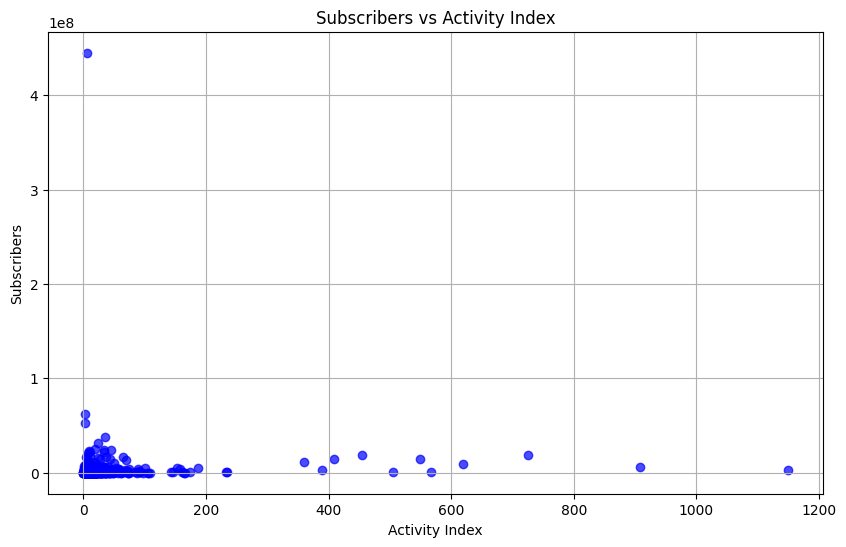

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_cleaned['ActivityIndex'] = df_cleaned['VideoCount'] / df_cleaned['ChannelAge']

plt.figure(figsize=(10,6))
plt.scatter(df_cleaned['ActivityIndex'], df_cleaned['Subscribers'], color='blue', alpha=0.7)
plt.xlabel('Activity Index')
plt.ylabel('Subscribers')
plt.title('Subscribers vs Activity Index')
plt.grid(True)
plt.show()

/tmp/ipython-input-4194133758.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['ActivityIndex'] = df_cleaned['VideoCount'] / df_cleaned['ChannelAge']
/tmp/ipython-input-4194133758.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['log_ActivityIndex'] = np.log1p(df_cleaned['ActivityIndex'])
/tmp/ipython-input-4194133758.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

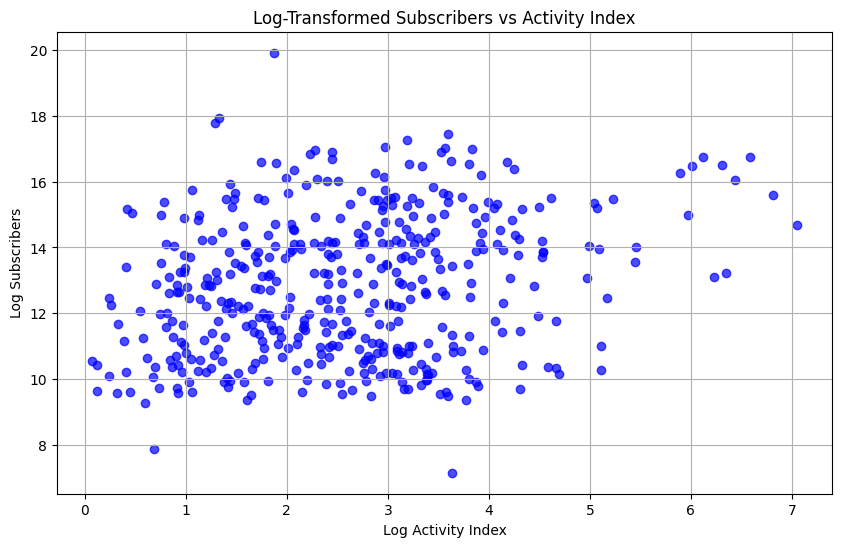

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_cleaned['ActivityIndex'] = df_cleaned['VideoCount'] / df_cleaned['ChannelAge']

df_cleaned['log_ActivityIndex'] = np.log1p(df_cleaned['ActivityIndex'])
df_cleaned['log_Subscribers'] = np.log1p(df_cleaned['Subscribers'])

plt.figure(figsize=(10,6))
plt.scatter(df_cleaned['log_ActivityIndex'], df_cleaned['log_Subscribers'], color='blue', alpha=0.7)
plt.xlabel('Log Activity Index')
plt.ylabel('Log Subscribers')
plt.title('Log-Transformed Subscribers vs Activity Index')
plt.grid(True)
plt.show()

In [ ]:
df_check = df_cleaned[df_cleaned['ChannelAge'] == 0]

print("Channels with ActivityIndex = inf:")
df_check

Channels with ActivityIndex = inf:


,Channel_ID,Channel_Title,PublishedAt,Subscribers,VideoCount,FormattedDate,ChannelAge,ActivityIndex


In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df_cleaned['ActivityIndex'], df_cleaned['Subscribers'])

print(f"Pearson correlation: {corr}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject H₀: There is enough evidence to suggest that ActivityIndex significantly affects Subscribers.")
else:
    print("Fail to reject H₀: There is not enough evidence to suggest that ActivityIndex affects Subscribers.")

Pearson correlation: 0.042843739811802714
P-value: 0.3716034167697606
Fail to reject H₀: There is enough evidence to suggest that ActivityIndex affects Subscribers.


# Research Question 2

## Hyphothesis 2

1.   H₀ (null): The most frequently used keywords (top 30) in a video title has no significant relationship with video popularity.
2.   H₁ (alternative): The most frequently used keywords (top 30) in a video title has a positive relationship with video popularity.


In [ ]:
df_2 = df_videos.sort_values(by='Views', ascending=False)
all_titles = " ".join(df_2['Title'].str.lower())
df_2

,Title,Channel,Channel_ID,Duration,Views,Likes,Category
371,100 Kids Vs World's Strongest Man!,MrBeast,UCX6OQ3DkcsbYNE6H8uQQuVA,PT27M21S,74790833,1970157,Entertainment
430,"Gainesville, FL doorbell camera captured the m...",Pouya Hashemi,UCq4HmIQ8hOQxYqWq3Cv1jVA,PT10S,58518278,753379,Howto & Style
100,Taylor Swift - The Fate of Ophelia (Official M...,Taylor Swift,UCqECaJ8Gagnn7YCbPEzWH6g,PT3M59S,52629858,1397913,Music
471,The wisdom of Rumi,DemonHunters-Rumi,UCTvxK-N-xRf7kUJNOxnl0dA,PT1M,42952667,1494290,Howto & Style
84,how to resolve cars like this #driving #truckd...,Driver Lover,UCxb5y7usqPLCxo-sBYNBiiw,PT1M2S,40736927,2622824,Autos & Vehicles
...,...,...,...,...,...,...,...
270,a fall weekend in new york city vlog 🍝🚕🗽,Tara Michelle,UCN0jjRU6bdRf1vEmvpoyveg,PT29M30S,29884,1714,People & Blogs
279,"A Day In Our Life! |Working Out Together, New ...",Riss & Quan Vlogs,UCH2QT_33C81WQwFsRJjGuxA,PT15M7S,28971,3609,People & Blogs
275,HOUSE TOUR...!!! Her First Time | VLOG#2121,Forever Family Vlogs,UCCavka0AbNklF4cqfaiwqEA,PT24M19S,27579,878,People & Blogs
277,How we do Chores + Cleaning and Building + Asi...,The Happy Caravan,UCbHu1p2qQz-C0LQftzzSmwA,PT33M21S,27413,2144,People & Blogs


In [ ]:
import re
from collections import Counter

words = re.findall(r'\b[a-z]{3,}\b', all_titles)
common_words = Counter(words).most_common(50)
print(common_words)

[('the', 145), ('shorts', 76), ('this', 49), ('and', 36), ('for', 33), ('you', 24), ('video', 22), ('car', 21), ('with', 21), ('his', 20), ('cat', 19), ('official', 18), ('how', 17), ('they', 17), ('she', 17), ('music', 16), ('got', 16), ('dog', 15), ('was', 14), ('new', 14), ('trump', 14), ('funny', 13), ('first', 13), ('are', 12), ('baby', 11), ('ever', 11), ('just', 11), ('from', 11), ('day', 11), ('edit', 10), ('get', 10), ('that', 10), ('one', 10), ('viral', 10), ('vlog', 10), ('brainrot', 10), ('our', 10), ('life', 10), ('real', 9), ('her', 9), ('why', 9), ('fyp', 9), ('best', 9), ('steal', 9), ('cars', 8), ('like', 8), ('does', 8), ('iphone', 8), ('when', 8), ('game', 8)]


In [ ]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

clickbait_words = [(w) for w, c in common_words if w not in stop_words]
print(len(clickbait_words))

30


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def contains_clickbait(title):
    title = title.lower()
    return any(word in title for word in clickbait_words)

df_2['Has_Clickbait'] = df_2['Title'].apply(contains_clickbait)
df_2.head()

,Title,Channel,Channel_ID,Duration,Views,Likes,Category,Has_Clickbait
371,100 Kids Vs World's Strongest Man!,MrBeast,UCX6OQ3DkcsbYNE6H8uQQuVA,PT27M21S,74790833,1970157,Entertainment,False
430,"Gainesville, FL doorbell camera captured the m...",Pouya Hashemi,UCq4HmIQ8hOQxYqWq3Cv1jVA,PT10S,58518278,753379,Howto & Style,True
100,Taylor Swift - The Fate of Ophelia (Official M...,Taylor Swift,UCqECaJ8Gagnn7YCbPEzWH6g,PT3M59S,52629858,1397913,Music,True
471,The wisdom of Rumi,DemonHunters-Rumi,UCTvxK-N-xRf7kUJNOxnl0dA,PT1M,42952667,1494290,Howto & Style,False
84,how to resolve cars like this #driving #truckd...,Driver Lover,UCxb5y7usqPLCxo-sBYNBiiw,PT1M2S,40736927,2622824,Autos & Vehicles,True


In [ ]:
df_2['Has_Clickbait'].value_counts()

,count
Has_Clickbait,
True,333
False,199


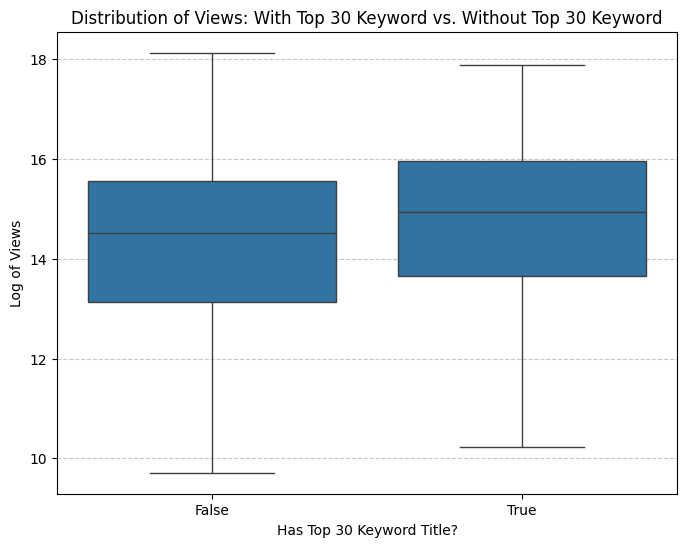

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_2['log_Views'] = np.log1p(df_2['Views'])

plt.figure(figsize=(8, 6))
sns.boxplot(x='Has_Clickbait', y='log_Views', data=df_2)

plt.title('Distribution of Views: With Top 30 Keyword vs. Without Top 30 Keyword')
plt.xlabel('Has Top 30 Keyword Title?')
plt.ylabel('Log of Views')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df_2['Has_Clickbait'], df_2['Views'])

print(f"Pearson correlation: {corr}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject H₀: There is enough evidence to suggest that most frequently used keywords in title positively affects video views.")
else:
    print("Fail to reject H₀: There is not enough evidence to suggest that most frequently used keywords in title positively affects video views.")

Pearson correlation: 0.10691301351370505
P-value: 0.013704922309818474
Reject H₀: There is enough evidence to suggest that most fruequently used keywords in title positively affects video views.
